# Practice Set 15: Capstone Visualizations

**Objective:** Create three publication-quality visualizations that support your capstone project's narrative.

---

## Learning Objectives
By completing this problem set, you will:
- Select appropriate visualization types for different data and questions
- Apply ggplot2 best practices for clear, effective communication
- Create visualizations that tell a coherent story about your data
- Write captions that help readers interpret your figures

---

## Instructions

1. **Use your own capstone data** for all three visualizations
2. Each visualization should serve a **different purpose** (see requirements below)
3. All visualizations must include:
   - Clear, descriptive title
   - Labeled axes with units where appropriate
   - Legend (if applicable)
   - Clean theme (e.g., `theme_minimal()`, `theme_bw()`)
4. Write a brief caption (2-3 sentences) explaining what each visualization shows

---

## Setup
Load the required packages and your capstone data.

In [7]:
# Load packages
library(tidyverse)
library(scales)      # For nice axis formatting
library(ggthemes)    # Optional: additional themes
library(terra)
library(viridis)


In [6]:
# Load your capstone data
# Replace the path below with your actual data file
mls_height <- terra::rast("/home/user/Capstone-Project-Template/Capstone-AGB-Remote-Sensing/processed_data/GEM_F3_CHM_1m_clipped_EPSG32637.tif")
field_height <- terra::rast("/home/user/Capstone-Project-Template/Capstone-AGB-Remote-Sensing/processed_data/field_max_height_raster.tif")

# Preview your data
glimpse(mls_height)
glimpse(field_height)

S4 class 'SpatRaster' [package "terra"]


S4 class 'SpatRaster' [package "terra"]


---

## Visualization 1: Distribution or Composition (15 points)

**Purpose:** Show how your data is distributed or composed.

### Suggested plot types:
- **Histogram** – distribution of a continuous variable
- **Density plot** – smoothed distribution
- **Boxplot** – distribution across groups
- **Bar chart** – counts or proportions of categories
- **Pie/donut chart** – composition (use sparingly)

### Requirements:
- [ ] Shows the distribution OR composition of at least one key variable
- [ ] Includes appropriate title and axis labels
- [ ] Uses color meaningfully (not just decoratively)
- [ ] Caption explains what pattern or insight the reader should notice

### Questions to consider:
- What is the shape of your data's distribution? (Normal? Skewed? Bimodal?)
- Are there outliers that need explanation?
- How do distributions differ across groups?

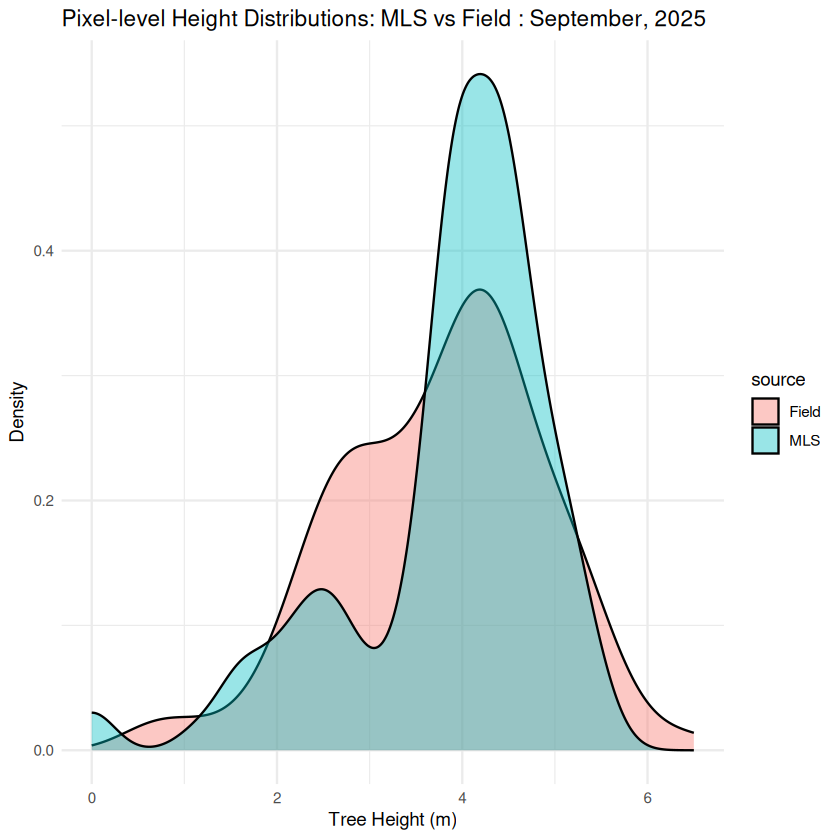

In [8]:
# VISUALIZATION 1: Density plot for MLS and field tree heights 
# Your code here
mls_vals   <- values(mls_height)
field_vals <- values(field_height)

# Remove NA pixels (pixels that are missing in either raster)
valid <- !is.na(mls_vals) & !is.na(field_vals)
mls_vals   <- mls_vals[valid]
field_vals <- field_vals[valid]

height_long <- data.frame(
  height = c(mls_vals, field_vals),
  source = c(
    rep("MLS", length(mls_vals)),
    rep("Field", length(field_vals))
  )
)

viz1 <- ggplot(height_long, aes(x = height, fill = source)) +
  geom_density(alpha = 0.4) +
  labs(
    x = "Tree Height (m)",
    y = "Density",
    title = "Pixel-level Height Distributions: MLS vs Field : September, 2025"
  ) +
  theme_minimal()

viz1

### Caption for Visualization 1

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 1:** This is a pixel level Canopy Height Model \(CHM\) validation plot, where the MLS height are generally higher that the field CHM heights for taller trees. The overlap areas shows that the mid\-sized trees are roughly matching for both methodologies. This visualization matters because I now have a picture of the distribution both datasets.


---

## Visualization 2: Relationship or Comparison (15 points)

**Purpose:** Show a relationship between variables OR compare groups.

### Suggested plot types:
- **Scatterplot** – relationship between two continuous variables
- **Line plot** – trends over time or sequence
- **Grouped bar chart** – comparing categories across groups
- **Faceted plots** – same relationship across subgroups
- **Correlation heatmap** – relationships among multiple variables

### Requirements:
- [ ] Shows a relationship between at least two variables OR compares groups
- [ ] Includes appropriate title and axis labels
- [ ] Uses `geom_smooth()`, trend lines, or reference lines if appropriate
- [ ] Caption explains the relationship or comparison and its significance

### Questions to consider:
- Is the relationship positive, negative, or nonlinear?
- Are there subgroups that behave differently?
- What is the practical significance of this relationship for your capstone question?

[1] 0.3918696

`geom_smooth()` using formula = 'y ~ x'


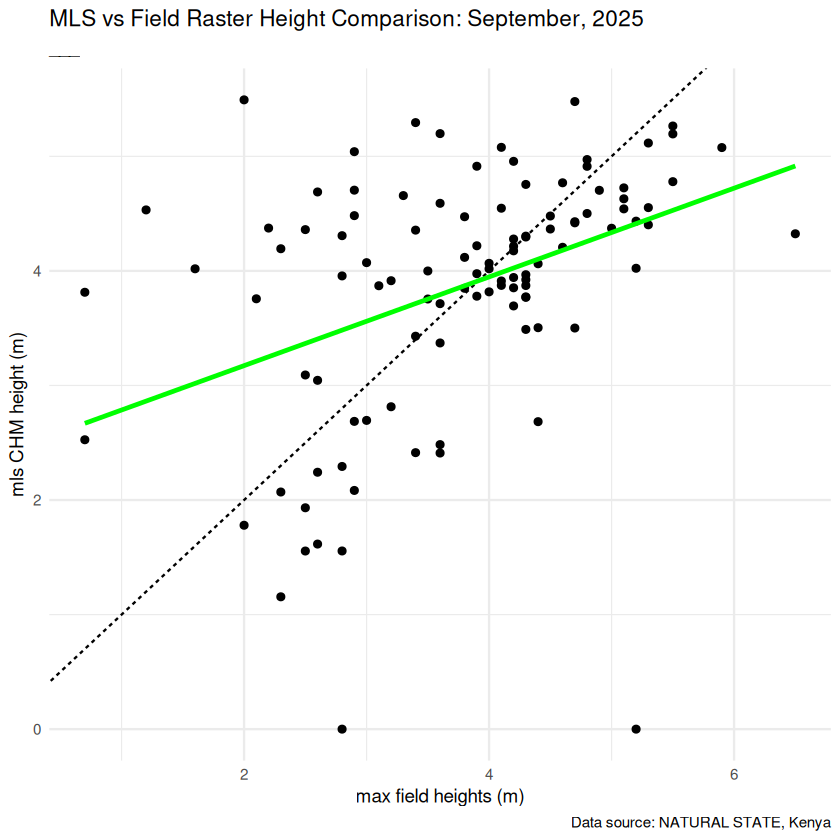

In [9]:
# VISUALIZATION 2: Relationship or Comparison
# Your code here
library(ggplot2)

# Combine MLS and Field pixel values into a dataframe
height_df <- data.frame(
  Field = field_vals,
  MLS   = mls_vals
)

# Scatter plot
viz2 <- ggplot(height_df, aes(x = Field, y = MLS)) +
  geom_point() +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  geom_smooth(method = "lm", se = FALSE, color = "green") +
  labs(
    title = "MLS vs Field Raster Height Comparison: September, 2025",
    subtitle = "___",
    x = "max field heights (m)",
    y = "mls CHM height (m)",
    caption = "Data source: NATURAL STATE, Kenya"
  ) +
  theme_minimal()

correlation <- cor(height_df$Field, height_df$MLS, use = "complete.obs")
correlation

viz2

### Caption for Visualization 2

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 2:**The MLS\-derived heights show a positive but weak correlation with field\-measured heights \(r = 0.39\). The regression slope indicates compression of the height range, with overestimation at lower field heights and underestimation at higher values, suggesting systematic bias in the MLS model.


---

## Visualization 3: Change Over Time or Space (15 points)

**Purpose:** Show how something changes across time, geography, or another ordered dimension.

### Suggested plot types:
- **Line chart** – trends over time
- **Area chart** – cumulative changes over time
- **Map** – spatial patterns (if you have geographic data)
- **Slope chart** – change between two time points
- **Faceted time series** – trends across multiple groups

### Requirements:
- [ ] Shows change across time, space, or another meaningful sequence
- [ ] Time axis is properly formatted (if applicable)
- [ ] Key events, thresholds, or reference points are annotated (if relevant)
- [ ] Caption explains the trend and its implications for your capstone

### Questions to consider:
- Is there a clear trend (increasing, decreasing, cyclical)?
- Are there notable events or breakpoints?
- How does this temporal/spatial pattern connect to your research question?

x,y,height,type
<dbl>,<dbl>,<dbl>,<chr>
317206.5,23473.5,0,MLS
317207.5,23473.5,0,MLS
317208.5,23473.5,0,MLS
317209.5,23473.5,0,MLS
317210.5,23473.5,0,MLS
317211.5,23473.5,0,MLS
317212.5,23473.5,0,MLS
317213.5,23473.5,0,MLS
317214.5,23473.5,0,MLS


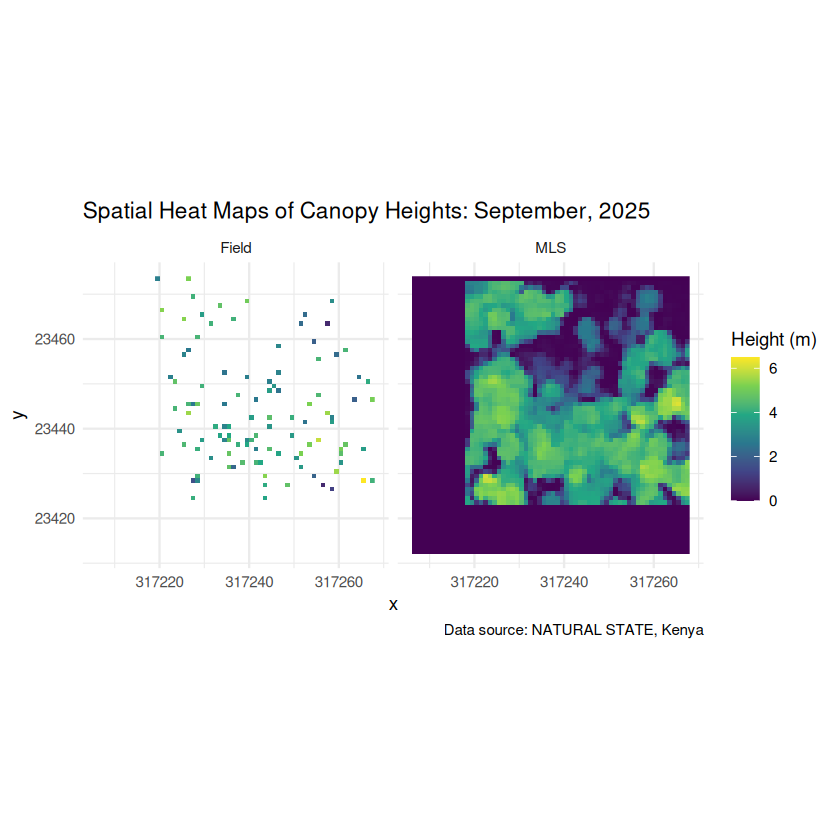

In [13]:
# VISUALIZATION 3: Change Over Time or Space
# Your code here
# Convert mls raster to data frame
mls_df <- as.data.frame(mls_height, xy = TRUE)

# Rename the value column to 'height'
names(mls_df)[3] <- "height"
mls_df$type <- "MLS"

# Convert field raster to data frame
field_df <- as.data.frame(field_height, xy = TRUE)

# Rename the value column to 'height'
names(field_df)[3] <- "height"
field_df$type <- "Field"

height_df <- bind_rows(mls_df, field_df)

height_df

# Plot heat map
viz3 <- ggplot(height_df, aes(x = x, y = y, fill = height)) +
  geom_raster() +
  scale_fill_viridis_c(name = "Height (m)") +
  coord_equal() +
  labs(
    title = "Spatial Heat Maps of Canopy Heights: September, 2025",
    caption = "Data source: NATURAL STATE, Kenya"
  ) +
  facet_wrap(~type) +   # creates separate heatmaps for MLS and Field
  theme_minimal()

# Display the plot
viz3

### Caption for Visualization 3

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 3:** The heat maps shows the distribution of tree heights in F3, 50m by 50m plot in the field ground\-truth heights and mobile laser scanner \(mls\) devise. This backs up the viz1 where the mid\-size trees are correctly measured by the mls where its overestimating the tall trees.



---

## Reflection Questions (5 points)

Answer the following questions in 2-4 sentences each.

### Question 1

**How do your three visualizations work together to tell a story about your capstone project?**

_Your answer: From the visualizations, the mls height accuracy is not reliable yet and therefore, more technology improvement is required._


### Question 2

**Which visualization was most challenging to create, and why?**

_Your answer: viz3 was challenging to create because it needed seperate data preparation which includes create a one dataframe with  x and y coordinates for both datasets._


### Question 3

**What is one thing you would improve about your visualizations if you had more time?**

_Your answer: I would want the visualizations to be interpretable even for non\-technical/ scientists_


---

## Grading Rubric (50 points total)

| Component | Points | Criteria |
|-----------|--------|----------|
| Visualization 1 | 15 | Appropriate type, clear labels, meaningful use of color, insightful caption |
| Visualization 2 | 15 | Shows relationship/comparison clearly, proper formatting, informative caption |
| Visualization 3 | 15 | Shows change effectively, proper time/space formatting, relevant caption |
| Reflection | 5 | Thoughtful answers demonstrating understanding of visualization choices |

### What makes a visualization "publication quality"?
- Readable fonts and appropriate sizing
- Clear hierarchy (title > subtitle > labels > caption)
- Minimal chart junk (no unnecessary gridlines, borders, or decoration)
- Accessible colors (consider colorblind-friendly palettes)
- Self-contained (a reader can understand it without reading surrounding text)

---

## Helpful Code Snippets

### Formatting dates on x-axis
```r
scale_x_date(date_labels = "%b %Y", date_breaks = "3 months")
```

### Adding a trend line
```r
geom_smooth(method = "lm", se = FALSE, color = "red")
```

### Faceting by a variable
```r
facet_wrap(~category_variable, scales = "free_y")
```

### Colorblind-friendly palette
```r
scale_color_brewer(palette = "Set2")
scale_fill_viridis_d()
```

### Adding annotations
```r
annotate("text", x = date_value, y = y_value, label = "Event", hjust = 0)
geom_vline(xintercept = as.Date("2020-03-15"), linetype = "dashed")
```

### Saving high-resolution figures
```r
ggsave("figure1.png", viz1, width = 8, height = 6, dpi = 300)
```

---

## Submission

Submit the following:
1. This completed notebook (.ipynb file)
2. Three separate image files of your visualizations (.png, 300 dpi)

**Naming convention:** `LastName_FirstName_capstone_viz.ipynb`